Breguet Theoretical Range Validation: 2958.24 km


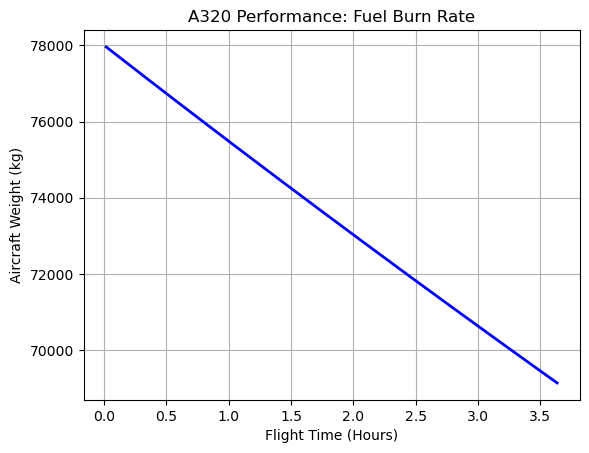

In [1]:
import matplotlib.pyplot as plt
import math
from atmosphere_model import calculate_isa
from aerodynamics import get_aero_forces
from propulsion import get_fuel_burn_rate

# A320 Baseline Variables
S = 122.6          
MTOW = 78000       
ZFW = 60000        
W_start = MTOW
TSFC = 1.6e-5      
CD0 = 0.02         
K = 0.04           
V_cruise = 230     
cruise_alt = 10000 
time_step = 60     

target_distance_m = 3000000 
current_distance = 0
current_weight = W_start

time_log, weight_log, altitude_log = [], [], []

while current_distance < target_distance_m and current_weight > ZFW:
    T, P, rho = calculate_isa(cruise_alt)
    CL, CD, drag = get_aero_forces(current_weight, rho, V_cruise, S, CD0, K)
    
    fuel_burned = get_fuel_burn_rate(drag, TSFC) * time_step

    
    current_weight -= fuel_burned
    current_distance += V_cruise * time_step
    
    time_log.append(current_distance / V_cruise / 3600)
    weight_log.append(current_weight)
    altitude_log.append(cruise_alt)

# Breguet Range Validation
L_D_ratio = CL / CD
breguet_range = (V_cruise / (9.81 * TSFC)) * L_D_ratio * math.log(W_start / current_weight)
print(f"Breguet Theoretical Range Validation: {breguet_range/1000:.2f} km")

# Visualization
plt.plot(time_log, weight_log, color='blue', linewidth=2)
plt.title("A320 Performance: Fuel Burn Rate")

plt.xlabel("Flight Time (Hours)")
plt.ylabel("Aircraft Weight (kg)")
plt.grid(True)
plt.show()